# Session 22 - Neural Networks for NLP (Hands-On)
### From Feed-Forward Nets to RNNs, LSTMs and GRUs

This notebook is the practical half of Session 22. We build a **character-level text generator** and
grow it step by step:

1. **Setup & data** - a tiny text corpus, turned into numbers.
2. **Embedding layer** - how word/character IDs become learnable vectors.
3. **Feed-forward baseline** - predict the next character from a *fixed window*. See why that is limiting.
4. **Vanilla RNN** - add memory so the model reads the sequence in order.
5. **Vanishing gradients** - a short experiment showing *why* simple RNNs forget.
6. **LSTM & GRU** - gated cells that protect long-term memory (one-line swaps).
7. **Compare** - put the loss curves side by side.

> **Goal:** build intuition for *why each idea was invented*. We are not trying to train a perfect model -
> everything is kept small so it runs in a couple of minutes on a laptop CPU.


## 0. Setup

We only need PyTorch and matplotlib. Setting a random seed keeps results reproducible.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.12.1+cpu | device: cpu


## 1. The data: characters as numbers

A neural network only understands numbers, so the first job is always to turn text into integers.

For a **character-level** model the vocabulary is just the set of unique characters. We build two small
dictionaries: `stoi` (string -> integer) and `itos` (integer -> string).

We use a short, repetitive corpus on purpose - repetition means even a tiny model can learn the pattern
quickly so the *ideas* are visible without a long training run.

In [2]:
text = (
    "the cat sat on the mat. "
    "the dog ran in the fog. "
    "the bird sang on the wire. "
    "the fish swam in the dish. "
) * 40   # repeat so the model has enough to learn from

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

def encode(s): return [stoi[c] for c in s]
def decode(ids): return "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
print("Corpus length:", len(text), "characters")
print("Vocabulary (", vocab_size, "chars ):", "".join(chars))
print("Encoded 'the cat' ->", encode("the cat"))

Corpus length: 4080 characters
Vocabulary ( 18 chars ):  .abcdefghimnorstw
Encoded 'the cat' -> [16, 9, 6, 0, 4, 2, 16]


## 2. The embedding layer

Before any recurrence, every character ID is turned into a vector by an **embedding layer**.

Think of `nn.Embedding(vocab_size, embed_dim)` as a **lookup table** with one row per character. The rows
start random and are *learned* together with the rest of the network. Below we look up three characters and
see that each becomes a small vector.

In [3]:
embed_dim = 16
embedding = nn.Embedding(vocab_size, embed_dim)

sample_ids = torch.tensor(encode("cat"))
vectors = embedding(sample_ids)

print("Lookup table shape (vocab x dim):", embedding.weight.shape)
print("'cat' -> 3 IDs:", sample_ids.tolist())
print("Each ID becomes a", embed_dim, "-dim vector. Vector for 'c':")
print(vectors[0].detach().round(decimals=2))

Lookup table shape (vocab x dim): torch.Size([18, 16])
'cat' -> 3 IDs: [4, 2, 16]
Each ID becomes a 16 -dim vector. Vector for 'c':
tensor([-0.5700,  0.9200,  1.1100,  1.2900, -1.4800,  2.5700, -0.4700,  0.3400,
        -1.6300, -0.5500, -0.4800, -0.5000, -1.0700,  1.1100, -0.1400,  0.8100])


## 3. A feed-forward baseline (fixed window)

Our first model is a plain **feed-forward network (FFN)**. It looks at a *fixed window* of the previous
`block` characters, flattens their embeddings into one long vector, and predicts the next character.

This works - but notice the built-in weakness: **the window size is fixed**. The model literally cannot see
anything older than `block` characters, no matter how important it was.

In [4]:
block = 8   # how many previous characters the FFN can see

def make_windows(data, block):
    X, Y = [], []
    for i in range(len(data) - block):
        X.append(data[i:i+block])
        Y.append(data[i+block])
    return torch.stack(X), torch.tensor(Y)

Xb, Yb = make_windows(data, block)
print("Inputs:", Xb.shape, "Targets:", Yb.shape)

class FFN(nn.Module):
    def __init__(self, vocab, dim, block, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(vocab, dim)
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(block * dim, hidden), nn.Tanh(),
            nn.Linear(hidden, vocab),
        )
    def forward(self, x):
        return self.net(self.emb(x))

def train(model, X, Y, steps=600, batch=128, lr=3e-3, log=150):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    history = []
    for s in range(steps):
        idx = torch.randint(0, len(X), (batch,))
        logits = model(X[idx])
        loss = lossf(logits, Y[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        history.append(loss.item())
        if s % log == 0 or s == steps-1:
            print(f"  step {s:4d}  loss {loss.item():.3f}")
    return history

ffn = FFN(vocab_size, embed_dim, block).to(device)
print("Training feed-forward baseline...")
ffn_hist = train(ffn, Xb, Yb)

Inputs: torch.Size([4072, 8]) Targets: torch.Size([4072])
Training feed-forward baseline...


  step    0  loss 2.977
  step  150  loss 0.038


  step  300  loss 0.013
  step  450  loss 0.043


  step  599  loss 0.023


### Generate text from the FFN

To sample, we keep a rolling window of the last `block` characters, ask the model for the next one,
append it, and slide the window forward.

In [5]:
@torch.no_grad()
def sample_ffn(model, prompt="the ", n=120, block=block):
    ids = encode(prompt)
    for _ in range(n):
        ctx = torch.tensor(ids[-block:]).unsqueeze(0)
        if ctx.shape[1] < block:   # left-pad if prompt is short
            pad = torch.zeros(1, block - ctx.shape[1], dtype=torch.long)
            ctx = torch.cat([pad, ctx], dim=1)
        probs = model(ctx).softmax(-1)
        nxt = torch.multinomial(probs, 1).item()
        ids.append(nxt)
    return decode(ids)

print(sample_ffn(ffn))

the dat sat on the wire. the fish swam in the dish. the cat sat on the mat. the dog ran in the dish. the cat sat on the wire


The FFN already produces word-like text. But it has no memory beyond its fixed window. To read sequences
of *any* length and carry information forward, we need a **recurrent** network.

## 4. The vanilla RNN

A recurrent neural network reuses **one cell** at every time step, passing a **hidden state** (its memory)
from each step to the next. The picture below is the classic way to show it - the same cell on the left,
"unrolled" across time on the right.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/Recurrent_neural_network_unfold.svg/640px-Recurrent_neural_network_unfold.svg.png" width="620" alt="RNN folded vs unrolled (fdeloche, CC BY-SA 4.0)"/>

*Recurrent neural network, folded vs unrolled. Source: Wikimedia Commons, fdeloche, CC BY-SA 4.0.*

In PyTorch we get this for free with `nn.RNN`. Now the input is a **whole sequence**, and the model
predicts the next character at every position.

In [6]:
def make_sequences(data, seq_len):
    X, Y = [], []
    for i in range(0, len(data) - seq_len - 1, seq_len):
        X.append(data[i:i+seq_len])
        Y.append(data[i+1:i+seq_len+1])   # targets are inputs shifted by one
    return torch.stack(X), torch.stack(Y)

seq_len = 24
Xs, Ys = make_sequences(data, seq_len)
print("Sequence inputs:", Xs.shape, "targets:", Ys.shape)

class RNNModel(nn.Module):
    """One class, three flavours: swap cell='rnn'/'lstm'/'gru'."""
    def __init__(self, vocab, dim, hidden=128, cell="rnn"):
        super().__init__()
        self.emb = nn.Embedding(vocab, dim)
        rnns = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}
        self.rnn = rnns[cell](dim, hidden, batch_first=True)
        self.head = nn.Linear(hidden, vocab)
    def forward(self, x):
        out, _ = self.rnn(self.emb(x))   # out: (batch, seq, hidden)
        return self.head(out)            # logits at every position

def train_seq(model, X, Y, steps=600, batch=32, lr=3e-3, log=150):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    history = []
    for s in range(steps):
        idx = torch.randint(0, len(X), (batch,))
        logits = model(X[idx])                       # (B, T, vocab)
        loss = lossf(logits.reshape(-1, logits.size(-1)), Y[idx].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        history.append(loss.item())
        if s % log == 0 or s == steps-1:
            print(f"  step {s:4d}  loss {loss.item():.3f}")
    return history

rnn = RNNModel(vocab_size, embed_dim, cell="rnn").to(device)
print("Training vanilla RNN...")
rnn_hist = train_seq(rnn, Xs, Ys)

Sequence inputs: torch.Size([169, 24]) targets: torch.Size([169, 24])
Training vanilla RNN...
  step    0  loss 2.939


  step  150  loss 0.037


  step  300  loss 0.030


  step  450  loss 0.022


  step  599  loss 0.028


In [7]:
@torch.no_grad()
def sample_rnn(model, prompt="the ", n=120):
    model.eval()
    ids = encode(prompt)
    x = torch.tensor(ids).unsqueeze(0)
    emb = model.emb(x)
    out, h = model.rnn(emb)
    for _ in range(n):
        logits = model.head(out[:, -1])
        nxt = torch.multinomial(logits.softmax(-1), 1)
        ids.append(nxt.item())
        out, h = model.rnn(model.emb(nxt), h)   # feed one step, keep hidden state
    return decode(ids)

print(sample_rnn(rnn))

the dog ran in the fog. the bird sang on the wire. the fish swam in the dish. the cat sat on the mat. the dog ran in the fog


## 5. Why simple RNNs forget: the vanishing gradient

The vanilla RNN works on short sequences, but it struggles to connect things that are far apart. The reason
is the **vanishing gradient**.

When the network learns, the error signal travels *backward* through every time step. At each step it gets
multiplied by roughly the same factor. If that factor is below 1, multiplying it many times drives the
signal toward **zero** - so early steps receive almost no learning signal.

The experiment below makes this concrete. We push a signal through many `tanh` steps and measure how strong
the gradient is at each step counting back from the end.

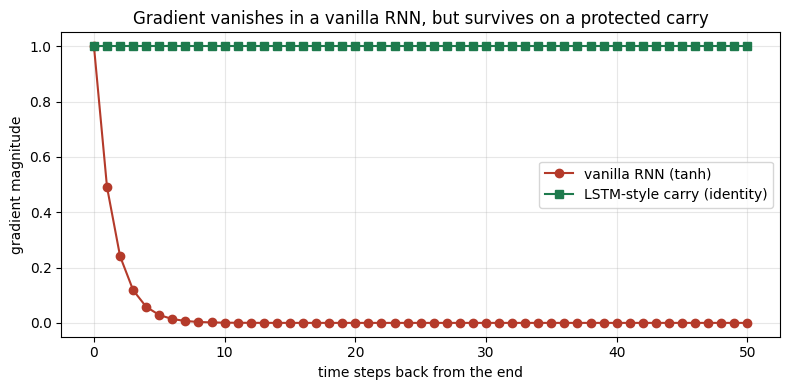

RNN gradient after 50 steps:   5.04e-16  (vanished)
Carry gradient after 50 steps: 1.00e+00  (preserved)


In [8]:
steps = 50
W = torch.tensor(0.6)          # recurrent weight < 1
h = torch.zeros(1, requires_grad=True)
hidden_states = [h]

for t in range(steps):
    h = torch.tanh(W * h + 0.2)
    h.retain_grad()            # so we can read the gradient at this step
    hidden_states.append(h)

hidden_states[-1].backward()   # gradient of the final state back through time

rnn_grads = [hs.grad.abs().item() for hs in hidden_states]

# Contrast: a linear "carry" like the LSTM cell state (c_t = c_{t-1} + small input)
c = torch.zeros(1, requires_grad=True)
carry_states = [c]
for t in range(steps):
    c = c + 0.0 * 1.0          # pure pass-through (identity)
    c.retain_grad()
    carry_states.append(c)
carry_states[-1].backward()
carry_grads = [cs.grad.abs().item() for cs in carry_states]

plt.figure(figsize=(8, 4))
plt.plot(range(steps+1), rnn_grads[::-1], 'o-', label="vanilla RNN (tanh)", color="#B43A2A")
plt.plot(range(steps+1), carry_grads[::-1], 's-', label="LSTM-style carry (identity)", color="#1E7A4D")
plt.xlabel("time steps back from the end")
plt.ylabel("gradient magnitude")
plt.title("Gradient vanishes in a vanilla RNN, but survives on a protected carry")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"RNN gradient after {steps} steps:   {rnn_grads[0]:.2e}  (vanished)")
print(f"Carry gradient after {steps} steps: {carry_grads[0]:.2e}  (preserved)")

The red curve collapses toward zero - the vanilla RNN cannot send a learning signal far back in time.
The green line stays flat: if memory can flow along an (almost) untouched path, the gradient survives. That
flat path is exactly the idea behind the **LSTM cell state**.

## 6. LSTM and GRU: gates that protect memory

### LSTM (Long Short-Term Memory)
The LSTM adds a separate **cell state** that runs straight across the top of the cell - a conveyor belt for
memory - plus three **gates** (forget / input / output) that decide what to remove, add, and reveal.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/63/Long_Short-Term_Memory.svg/640px-Long_Short-Term_Memory.svg.png" width="560" alt="LSTM cell (fdeloche, CC BY-SA 4.0)"/>

*LSTM cell. Source: Wikimedia Commons, fdeloche, CC BY-SA 4.0.*

### GRU (Gated Recurrent Unit)
The GRU is a streamlined version: just two gates (reset / update) and no separate cell state. Fewer
parameters, faster to train, often just as good.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/37/Gated_Recurrent_Unit%2C_base_type.svg/600px-Gated_Recurrent_Unit%2C_base_type.svg.png" width="520" alt="GRU cell (Jeblad, CC BY-SA 4.0)"/>

*GRU cell. Source: Wikimedia Commons, Jeblad, CC BY-SA 4.0.*

The best part in code: because we wrote `RNNModel` to accept a `cell` argument, switching architecture is a
**one-word change**.

In [9]:
lstm = RNNModel(vocab_size, embed_dim, cell="lstm").to(device)
print("Training LSTM...")
lstm_hist = train_seq(lstm, Xs, Ys)

gru = RNNModel(vocab_size, embed_dim, cell="gru").to(device)
print("\nTraining GRU...")
gru_hist = train_seq(gru, Xs, Ys)

Training LSTM...
  step    0  loss 2.888


  step  150  loss 0.044


  step  300  loss 0.028


  step  450  loss 0.025


  step  599  loss 0.022

Training GRU...
  step    0  loss 2.896


  step  150  loss 0.061


  step  300  loss 0.025


  step  450  loss 0.028


  step  599  loss 0.025


In [10]:
print("LSTM sample:\n ", sample_rnn(lstm))
print("\nGRU sample:\n ", sample_rnn(gru))

LSTM sample:
  the bird sang on the wire. the fish swam in the dish. the cat sat on the mat. the dog ran in the fog. the bird sang on the w

GRU sample:
  the cat sat on the mat. the dog ran in the fog. the bird sang on the wire. the fish swam in the dish. the cat sat on the mat


## 7. Putting the loss curves together

A quick smoothing function lets us compare how fast each model learns. On this tiny corpus all of them learn
the pattern; the point is the *shape* - and that swapping cells was effortless.

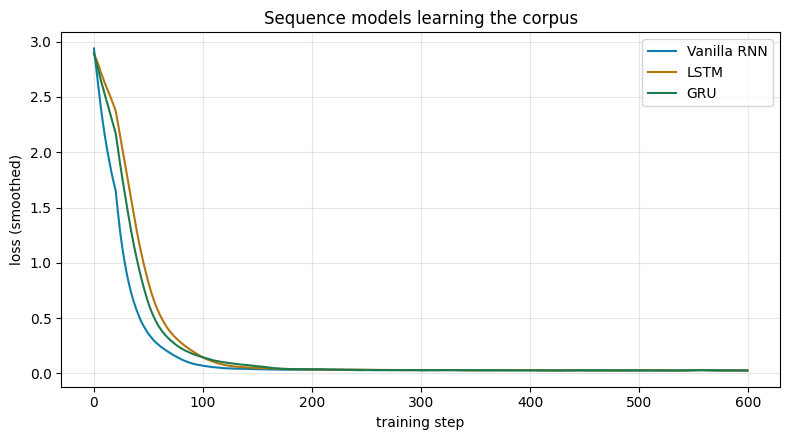

RNN   final loss: 0.027
LSTM  final loss: 0.026
GRU   final loss: 0.025


In [11]:
def smooth(x, k=20):
    out = []
    for i in range(len(x)):
        out.append(sum(x[max(0,i-k):i+1]) / len(x[max(0,i-k):i+1]))
    return out

plt.figure(figsize=(8, 4.5))
plt.plot(smooth(rnn_hist),  label="Vanilla RNN", color="#0E7FAB")
plt.plot(smooth(lstm_hist), label="LSTM",        color="#B4760A")
plt.plot(smooth(gru_hist),  label="GRU",         color="#1E7A4D")
plt.xlabel("training step"); plt.ylabel("loss (smoothed)")
plt.title("Sequence models learning the corpus")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

for name, h in [("RNN", rnn_hist), ("LSTM", lstm_hist), ("GRU", gru_hist)]:
    print(f"{name:5s} final loss: {sum(h[-20:])/20:.3f}")

## Recap

- An **embedding layer** turns character/word IDs into vectors that are learned with the model.
- A **feed-forward net** can predict from a *fixed window*, but cannot remember anything older than that.
- An **RNN** reuses one cell across the sequence, carrying a **hidden state** as memory.
- **Vanishing gradients** stop a vanilla RNN from learning long-range patterns (we measured it).
- **LSTMs** add a protected **cell state** + three gates; **GRUs** do the same job with two gates and fewer
  parameters.

**What's next:** the long-range memory problem we hit here is exactly what **attention** and
**Transformers** were built to solve - the topic that follows in the course.

---
*Image credits (Wikimedia Commons): RNN & LSTM diagrams by fdeloche (CC BY-SA 4.0); GRU diagram by Jeblad
(CC BY-SA 4.0).*

### Try it yourself
1. Increase the repetition factor on the corpus, or paste in your own text, and retrain.
2. Change `W` in the vanishing-gradient cell to `1.2` - watch the gradient **explode** instead.
3. Raise `hidden` from 128 to 256, or add `num_layers=2` to the RNN, and compare the samples.
